# Take-Home 1: Data Analysis

**QSS 20: Modern Statistical Computing | Dartmouth College | Spring 2026**

this take-home tests your ability to work with a real-world dataset using the Pandas skills covered in class. You have the weekend to complete it (**due Sunday night 11:59 PM EST**). 

Please see the **take-home packet** for full logistics, context, and grading details.

**Dataset:** Cook County felony sentencing data (`sentencing_asof0405.csv`)

**Total points:** 65

---
## 0. Setup (0 points)

Load the necessary packages and the sentencing dataset.

**Note:** You may receive a warning about mixed data types upon import; feel free to ignore it.

In [1]:
# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the sentencing dataset
df = pd.read_csv("sentencing_asof0405.csv", low_memory = False)
# low_memory = False necessary to read columns with mixed data types.

---
## 1. Data Inspection & Understanding (15 points)

### 1a. Print the dimensions of the dataset and the first few rows.

In [19]:
# Use the .shape attribute from the pandas package to print the dimensions of the dataset.
print(df.shape)

# dimensions = 248146 x 41

# quickly print the first few rows with the .head() method from the pandas package

data_head = df.head()
data_head

(248146, 41)


,CASE_ID,CASE_PARTICIPANT_ID,RECEIVED_DATE,OFFENSE_CATEGORY,PRIMARY_CHARGE_FLAG,CHARGE_ID,CHARGE_VERSION_ID,DISPOSITION_CHARGED_OFFENSE_TITLE,CHARGE_COUNT,DISPOSITION_DATE,...,INCIDENT_CITY,INCIDENT_BEGIN_DATE,INCIDENT_END_DATE,LAW_ENFORCEMENT_AGENCY,LAW_ENFORCEMENT_UNIT,ARREST_DATE,FELONY_REVIEW_DATE,FELONY_REVIEW_RESULT,ARRAIGNMENT_DATE,UPDATED_OFFENSE_CATEGORY
0,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50510112469,116304211997,FIRST DEGREE MURDER,2,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
1,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50510213021,98265074680,HOME INVASION,14,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
2,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50516447217,131972895911,FIRST DEGREE MURDER,4,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
3,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50516497493,131966356472,FIRST DEGREE MURDER,5,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
4,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50516648320,98059642859,HOME INVASION,13,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide


### 1b. How many unique cases (`CASE_ID`), participants (`CASE_PARTICIPANT_ID`), and charges (`CHARGE_ID`) are there? What does this tell you about the unit of analysis?

In [17]:
# Find the number of unique cases, participants, and charges with .nunique method. We select each relevant column of the dataframe

unique_cases = df["CASE_ID"].nunique()
print(f'number of unique cases = {unique_cases}')

unique_participants = df["CASE_PARTICIPANT_ID"].nunique()
print(f'number of unique participants = {unique_participants}')

unique_charges = df["CHARGE_ID"].nunique()
print(f'number of unique charges = {unique_charges}')

# The unit of analysis is by case. For each case, there may be multiple participants involved, and for each participant, multiple charges,
# and for each charge, multiple counts. 

number of unique cases = 197519
number of unique participants = 211977
number of unique charges = 229015


### 1c. In 2-3 sentences, describe what each row in this dataset represents and why the counts above differ.

*Each row in this dataset represents data on a crime committed. The dataset first sorts by the case ID; then by the participant and their background; and finally by the charges and number of counts associated with each charge. For each case, there may be multiple participants incurring multiple different charges and multiple counts of each charge.*



---
## 2. Data Cleaning (20 points)

### 2a. The variable `RACE` has many categories. Create a simplified variable called `race_clean` that identifies defendants as "Black", "White", "Hispanic", or "Other".

In [54]:
# First, make sure each entry is properly capitalized
df["RACE_CLEAN"] = df["RACE"].str.capitalize()

# The "RACE" column is quite tricky to deal with. I am sure there is a way to automate my condition with str.contains("Hispanic") but the issue is
# that other categories (Black, White) are included in the "White/black [hispanic or latino]" entry. I just bashed it.

races = ["Black", "White", "Hispanic", "Hispanic", "Hispanic"]

conditions = [df.RACE_CLEAN == "Black", 
              df.RACE_CLEAN == "White", 
              df.RACE_CLEAN == "Hispanic", 
              df.RACE_CLEAN == "White [hispanic or latino]",
              df.RACE_CLEAN == "White/black [hispanic or latino]"
             ]

# Create the column race_clean with the races input condition, labelling all other races as Other

df["RACE_CLEAN"] = np.select(conditions, races, default="Other")

# Old code, didn't work
# race_clean = df["RACE_CLEAN"].where(df["RACE_CLEAN"].isin(races), other="Other")

df["RACE_CLEAN"]

0         Black
1         Black
2         Black
3         Black
4         Black
          ...  
248141    Other
248142    Black
248143    White
248144    White
248145    White
Name: RACE_CLEAN, Length: 248146, dtype: object

### 2b. Print the value counts of the original `RACE` variable and the cleaned `race_clean` variable to validate your work.

In [66]:
# I noticed an NaN entry when I printed the df["RACE"] column. I looked up how to count these. I must use the dropna parameter.
print(df["RACE"].value_counts(dropna=False))

print(df["RACE_CLEAN"].value_counts())
# Now these add up clearly

RACE
Black                               164423
White [Hispanic or Latino]           37880
White                                35361
HISPANIC                              5941
Asian                                 1453
NaN                                   1267
White/Black [Hispanic or Latino]      1238
Unknown                                358
American Indian                        125
ASIAN                                   65
Biracial                                35
Name: count, dtype: int64
RACE_CLEAN
Black       164423
Hispanic     45059
White        35361
Other         3303
Name: count, dtype: int64


### 2c. Subset the data to only primary charges (`PRIMARY_CHARGE_FLAG` is True) so each defendant-case appears once. Print how many rows you started with and how many remain after subsetting.

In [72]:
# Apply boolean condition to df s.t. subsetted to all primary_charge_flag == True.
primary_charges_only = df[df["PRIMARY_CHARGE_FLAG"] == True]

# Display subsetted dataframe
display(primary_charges_only)

# Number of rows of the parent dataframe taken by indexing the 1st column.
print(f'number of rows of parent dataframe = {df.shape[0]}')

# Rows of the subsetted dataframe
print(f'number of rows of primary charges dataframe = {primary_charges_only.shape[0]}')

,CASE_ID,CASE_PARTICIPANT_ID,RECEIVED_DATE,OFFENSE_CATEGORY,PRIMARY_CHARGE_FLAG,CHARGE_ID,CHARGE_VERSION_ID,DISPOSITION_CHARGED_OFFENSE_TITLE,CHARGE_COUNT,DISPOSITION_DATE,...,INCIDENT_END_DATE,LAW_ENFORCEMENT_AGENCY,LAW_ENFORCEMENT_UNIT,ARREST_DATE,FELONY_REVIEW_DATE,FELONY_REVIEW_RESULT,ARRAIGNMENT_DATE,UPDATED_OFFENSE_CATEGORY,RACE_CAPITAL,RACE_CLEAN
9,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,True,50510062193,112898098217,FIRST DEGREE MURDER,1,12/17/2014 12:00:00 AM,...,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide,Black,Black
10,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,True,50510062193,112898098217,FIRST DEGREE MURDER,1,12/17/2014 12:00:00 AM,...,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide,Black,Black
15,150065796098,162105612284,8/23/1984 12:00:00 AM,PROMIS Conversion,True,50792360681,113332130159,FIRST DEGREE MURDER,1,8/6/2014 12:00:00 AM,...,NaN,CHICAGO POLICE DEPT,NaN,2/10/1983 12:00:00 AM,NaN,NaN,NaN,Homicide,Black,Black
16,150065796098,162105612284,8/23/1984 12:00:00 AM,PROMIS Conversion,True,50792360681,113332130159,FIRST DEGREE MURDER,1,8/6/2014 12:00:00 AM,...,NaN,CHICAGO POLICE DEPT,NaN,2/10/1983 12:00:00 AM,NaN,NaN,NaN,Homicide,Black,Black
18,154954734978,225758446387,6/8/2001 12:00:00 AM,PROMIS Conversion,True,54885211141,174293345821,VIO BAIL BOND/CLASS 1,1,12/2/2013 12:00:00 AM,...,NaN,HANOVER PARK POLICE DEPARTMENT,NaN,10/26/2000 12:00:00 AM,NaN,NaN,NaN,PROMIS Conversion,White [hispanic or latino],Hispanic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248141,445516248775,905289187184,2/3/2021 12:00:00 AM,Home Invasion,True,447867029248,836341344232,AGGRAVATED UNLAWFUL USE OF WEAPON,1,3/19/2021 12:00:00 AM,...,NaN,DES PLAINES PD,NaN,2/2/2021 2:20:00 PM,02/04/2021 12:00:00 AM,Approved,3/19/2021 12:00:00 AM,UUW - Unlawful Use of Weapon,NaN,Other
248142,445527409730,905322500577,2/4/2021 12:00:00 AM,Domestic Battery,True,447970697900,836537247156,DOMESTIC BATTERY,1,3/23/2021 12:00:00 AM,...,NaN,COOK COUNTY SHERIFF'S POLICE PATROL MAYWOOD (I...,NaN,2/9/2021 11:25:00 AM,02/10/2021 12:00:00 AM,Approved,3/11/2021 12:00:00 AM,Domestic Battery,Black,Black
248143,445587767000,905518794790,2/9/2021 12:00:00 AM,Driving With Suspended Or Revoked License,True,447955866546,837760215766,DRIVING ON SUSPENDED LICENSE,1,3/11/2021 12:00:00 AM,...,NaN,BERWYN PD,NaN,2/4/2021 4:35:00 PM,NaN,NaN,3/9/2021 12:00:00 AM,Driving With Suspended Or Revoked License,White,White
248144,445592613204,905533705601,2/9/2021 12:00:00 AM,Driving With Suspended Or Revoked License,True,447966223356,837758347354,DRIVING ON SUSPENDED LICENSE,1,3/11/2021 12:00:00 AM,...,NaN,BERWYN PD,NaN,2/4/2021 4:35:00 PM,NaN,NaN,3/9/2021 12:00:00 AM,Driving With Suspended Or Revoked License,White,White


number of rows of parent dataframe = 248146
numbwe of rows of primary charges dataframe = 180625


---
## 3. Descriptive Analysis (30 points)

Use your cleaned, primary-charge-only data for this section.

### 3a. Compute the incarceration rate by race.

According to the codebook, incarceration is indicated by `COMMITMENT_TYPE == "Illinois Department of Corrections"`. Present these rates in a table.

In [105]:
# Filter for the commitment type to Illinois jail
incarcerated = primary_charges_only[primary_charges_only["COMMITMENT_TYPE"] == "Illinois Department of Corrections"]

# Print new dataframe
display(incarcerated)

# Use number of rows in incarcerated dataframe and a lambda function to calculate the rate of incarceration per race.

inc_rate = incarcerated.agg({"RACE_CLEAN": lambda x: x.value_counts(normalize=True) * 100})
inc_rate.reset_index(drop=True)
inc_rate.index.name = "Race"
inc_rate.columns = ["Incarceration Rate"]
inc_rate

,CASE_ID,CASE_PARTICIPANT_ID,RECEIVED_DATE,OFFENSE_CATEGORY,PRIMARY_CHARGE_FLAG,CHARGE_ID,CHARGE_VERSION_ID,DISPOSITION_CHARGED_OFFENSE_TITLE,CHARGE_COUNT,DISPOSITION_DATE,...,INCIDENT_END_DATE,LAW_ENFORCEMENT_AGENCY,LAW_ENFORCEMENT_UNIT,ARREST_DATE,FELONY_REVIEW_DATE,FELONY_REVIEW_RESULT,ARRAIGNMENT_DATE,UPDATED_OFFENSE_CATEGORY,RACE_CAPITAL,RACE_CLEAN
9,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,True,50510062193,112898098217,FIRST DEGREE MURDER,1,12/17/2014 12:00:00 AM,...,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide,Black,Black
16,150065796098,162105612284,8/23/1984 12:00:00 AM,PROMIS Conversion,True,50792360681,113332130159,FIRST DEGREE MURDER,1,8/6/2014 12:00:00 AM,...,NaN,CHICAGO POLICE DEPT,NaN,2/10/1983 12:00:00 AM,NaN,NaN,NaN,Homicide,Black,Black
18,154954734978,225758446387,6/8/2001 12:00:00 AM,PROMIS Conversion,True,54885211141,174293345821,VIO BAIL BOND/CLASS 1,1,12/2/2013 12:00:00 AM,...,NaN,HANOVER PARK POLICE DEPARTMENT,NaN,10/26/2000 12:00:00 AM,NaN,NaN,NaN,PROMIS Conversion,White [hispanic or latino],Hispanic
28,155685924389,221749325828,6/15/2001 12:00:00 AM,PROMIS Conversion,True,55017536987,687589180737,AGGRAVATED CRIMINAL SEXUAL ASSAULT,1,5/3/2013 12:00:00 AM,...,NaN,C P D AREA 1 DIST 21,NaN,6/15/2001 5:05:00 PM,06/15/2001 12:00:00 AM,Charge(S) Approved,NaN,PROMIS Conversion,Black,Black
32,156558681704,231553844285,7/17/2001 12:00:00 AM,PROMIS Conversion,True,58235136444,720561595284,2ND DEGREE MURDER,1,12/4/2014 12:00:00 AM,...,NaN,C P D AREA 1,NaN,7/16/2001 12:00:00 AM,07/17/2001 12:00:00 AM,Charge(S) Approved,NaN,Homicide,Black,Black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248101,444757010121,902797855005,12/4/2020 12:00:00 AM,Credit Card Cases,True,446970360764,834641370221,IDENTITY THEFT,1,3/2/2021 12:00:00 AM,...,NaN,RIVERSIDE PD,NaN,12/3/2020 4:53:00 PM,12/04/2020 12:00:00 AM,Approved,1/12/2021 12:00:00 AM,Identity Theft,White,White
248119,444982872606,903587656097,9/19/2014 12:00:00 AM,Forgery,True,446915459615,834537766815,FORGERY,1,3/19/2021 12:00:00 AM,...,NaN,ROLLING MEADOWS PD,NaN,11/5/2020 6:55:00 PM,NaN,NaN,3/19/2021 12:00:00 AM,Forgery,Black,Black
248121,444997704928,903637201511,12/24/2020 12:00:00 AM,Aggravated Assault Police Officer,True,446942960465,836715587014,AGG ASSAULT/STATE OF IL EMP,1,2/17/2021 12:00:00 AM,...,NaN,WHEELING PD,NaN,11/12/2020 4:16:00 PM,NaN,NaN,2/17/2021 12:00:00 AM,Aggravated Assault Police Officer,White [hispanic or latino],Hispanic
248129,445140741379,904087923223,1/7/2021 12:00:00 AM,Possession of Stolen Motor Vehicle,True,447180111306,837593366637,ATTEMPT POSSESSION OF A STOLEN MOTOR VEHICLE,1,3/2/2021 12:00:00 AM,...,NaN,CHICAGO PD,NaN,1/6/2021 8:35:00 PM,01/07/2021 12:00:00 AM,Approved,2/19/2021 12:00:00 AM,Possession of Stolen Motor Vehicle,Black,Black


,Incarceration Rate
Race,
Black,73.418064
Hispanic,14.456486
White,11.372120
Other,0.753330


### 3b. Create a visualization (your choice of chart type) that clearly communicates the comparison of incarceration rates across racial groups.

Make sure your visualization has:
- A descriptive title
- Labeled axes
- A legend (if applicable)

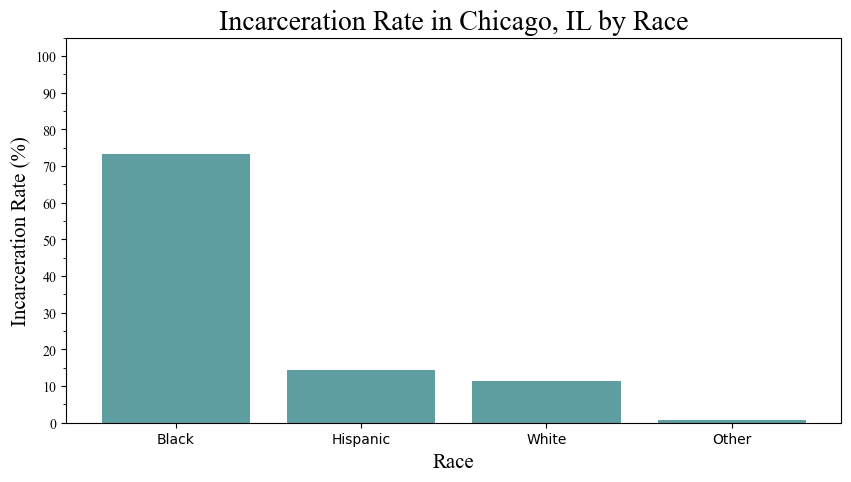

In [126]:
# Probably best to use a bar chart to compare frequencies across races. Easy to use the inc_rate data.
plt.figure(figsize=(10, 5))

# A legend seems kind of silly since I label the y-axis properly.
plt.bar(inc_rate.index, inc_rate["Incarceration Rate"], color="cadetblue")

major = np.arange(0, 105, 10)
minor = np.arange(0, 110, 5)

plt.yticks(minor, fontsize=5, fontname="Times New Roman", minor=True)
plt.yticks(major, fontsize=10, fontname="Times New Roman")
plt.xlabel("Race", fontsize=15, fontname="Times New Roman")
plt.ylabel("Incarceration Rate (%)", fontsize=15, fontname="Times New Roman")
plt.title("Incarceration Rate in Chicago, IL by Race", fontsize=20, fontname="Times New Roman")

plt.savefig("incarceration_rate.png", bbox_inches="tight")

